In [1]:
import numpy as np

from jax import numpy as jnp
from qeep import rec, rec_utils as ru, qeutils as qu
from qeep import qeresults as qres


import matplotlib.pyplot as plt

from abacusnbody.data.read_abacus import read_asdf

import numpy as np

from abacusnbody.analysis.tsc import tsc_parallel

import matplotlib.pyplot as plt

from abacusnbody.analysis.power_spectrum import calc_power, calc_pk_from_deltak, get_k_mu_edges
from abacusnbody.analysis import power_spectrum as ps

from scipy.fft import rfftn, irfftn

import astropy

from classy import Class

import yaml

from abacusnbody.analysis.power_spectrum import calc_power
from abacusnbody.data import read_abacus
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.ticker import LogLocator, LogFormatter, AutoMinorLocator
from matplotlib.gridspec import GridSpec
from matplotlib import patheffects
import matplotlib as mpl


plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm"  # Use Computer Modern math font
})


COLORBLIND_PALETTE = [
    '#0072B2',  # Blue
    '#D55E00',  # Orange
    '#009E73',  # Green
    '#CC79A7',  # Pink
    '#56B4E9',  # Light blue
    '#E69F00',  # Yellow
    '#000000',  # Black
    '#F0E442'   # Light yellow
]

# Use golden ratio for figure dimensions
GOLDEN_RATIO = (5**0.5 - 1) / 2
FIG_WIDTH = 5  # inches
FIG_HEIGHT = 3 * GOLDEN_RATIO
DPI = 300

import os
os.environ['PATH'] = os.path.expanduser("~/texlive/2025/bin/aarch64-linux") + ":" + os.environ['PATH']

style_path = "paper/paper.mplstyle"
plt.style.use(style_path)

In [2]:
scratch = "/capstor/scratch/cscs/odarwish/ABACUS/"

z = 0.5 #redshift of the simulation

box = 2000 #box size, in Gpc/h
nthread = 128 #number of threads to use for FFT calcs
ngrid = 576#*2, grid size on which to paste quantities

paste = 'TSC' #Triangular Shaped Cloud mass assignment scheme
interlaced = True #reduces aliasing artifacts in the power spectrum
compensated = True #applies mass assignment compensation (basically a deconvolution)

logk = False
k_hMpc_max = np.pi * ngrid / box + 1.0e-6
nbins_k = ngrid // 2
dtype = np.float32

In [75]:
simulations_results = {}

In [76]:
configuration = '../configs/abacus/config_abacus_recs.yaml'
configuration = '../configs/abacus/config_abacus_recs_kmax_10.yaml'
configuration = '../configs/abacus/config_abacus_recs_kmax_20_new_shot.yaml'

with open(configuration, 'r') as f:
    config = yaml.safe_load(f)

ps_main_directory = config['power_spectrum']['main_directory']
name_config = config['name']
gen_nl_power = np.loadtxt(ps_main_directory+name_config+"/"+config['power_spectrum']['nonlinear'])
gen_power = np.loadtxt(ps_main_directory+name_config+"/"+config['power_spectrum']['linear'])


output_config = config['output']
filename_prefix = output_config['filename_prefix']
filename_prefix = output_config['filename_prefix']
output_dir = Path(output_config['directory'])/config['name']

work_keys = ["t", "s", "g", "n"]

for simindex in [0, 1, 2, 3]:

    if simindex in simulations_results:
        continue

    print("Working on", simindex)

    simulations_results[simindex] = {}
    
    with open(configuration, 'r') as f:
        config = yaml.safe_load(f)
    
    filename_prefix = f"analysis_AbacusSummit_base_c000_ph{simindex:03}_z0.500_LRG_LRG"
    filename_prefix = f"analysis_AbacusSummit_base_c000_ph{simindex:03}_z0.500_LRG_ELG"
    
    QR = qres.QEResults(config, relative_path = ".", filename_prefix = filename_prefix)
    get_norm_opt = QR.get_get_norm()
    get_var_opt = QR.get_get_variance()
    get_bisp_opt = QR.get_get_bispectrum_mixed()
    get_trisp_opt = QR.get_get_trispectrum()
    
    
    #let's get some quantities from the abacus utils
    from abacusnbody.metadata import get_meta
    from abacusnbody.hod.zcv.ic_fields import load_dens, load_disp
    
    sim_name = f"{config['sim_params']['sim_name_base']}{simindex:03}"
    z = config['sim_params']['z_mock']
    
    meta = get_meta(sim_name, redshift=z)
    
    z_ic = meta['InitialRedshift']
    
    Dz = meta['GrowthTable']
    ztarget = 0.5
    zpk = meta['ZD_Pk_file_redshift']  # 1.0
    pk = meta['CLASS_power_spectrum']
    linear_k  = pk['k (h/Mpc)']
    input_pk = pk['P (Mpc/h)^3']
    linear_pk = input_pk * (Dz[ztarget] / Dz[zpk])**2
    
    D_ratio = meta['GrowthTable'][meta['Redshift']] / meta['GrowthTable'][z_ic] #re-scaling growth factor between initial redshift and current redshift
    
    #here we specify the inital conditions, useful to get the linear density field
    ic_dir = "/users/odarwish/scratch/ABACUS/ic/"
    ic = load_dens(ic_dir, sim_name, ngrid)*D_ratio
    ic_fft = rfftn(ic, overwrite_x=False, workers=nthread)
    ic_fft /= ic.size
    
    from jax import numpy as jnp
    from qeep import rec, rec_utils as ru, qeutils as qu
    
    pnlinf = lambda kmag: jnp.interp(kmag, gen_nl_power[:,0], gen_nl_power[:,1])
    plinf = lambda kmag: jnp.interp(kmag, gen_power[:,0], gen_power[:,1])
    kmin, kmax = config['k_range']['kmin'], config['k_range']['kmax'] #kmin, kmax of reconstruction
    
    #here we are loading some simulation results
    #we used the ZCV utils from abacusutils to get this info
    z_mock = 0.5
    scratch = f"/users/odarwish/scratch/ABACUS/abacus_out/{sim_name}/z{z_mock:.3f}/galaxies/"
    
    samples = ["LRG", "ELG"]
    
    trA, trB = samples
    
    out_info_A = np.load(scratch+f"{samples[0]}_out_info.npy", allow_pickle=True).item()
    out_info_B = np.load(scratch+f"{samples[1]}_out_info.npy", allow_pickle=True).item()

    direc_m = "/capstor/scratch/cscs/odarwish/ABACUS/"
    delta_m = np.load(direc_m+f"delta_matter_{simindex}.npy")
    
    kr_config = config['k_range']
    kmin = kr_config['kmin']
    kmax = kr_config['kmax']
    k_samples = kr_config['k_samples']
    k_min_analysis = kr_config['k_min_analysis']
    k_max_analysis = kr_config['k_max_analysis']
    
    kmin_max = 2*k_min_analysis
    Ks_ = np.linspace(k_min_analysis, kmin_max, 20)
    Ks = np.logspace(np.log10(kmin_max), np.log10(k_max_analysis), k_samples)
    Ks = np.concatenate([Ks_, Ks])
    Ks = np.unique(Ks)
    
    W = ps.get_W_compensated(box, ngrid, paste, interlaced)
    
    f = (
        W[:, np.newaxis, np.newaxis]
        * W[np.newaxis, :, np.newaxis]
        * W[np.newaxis, np.newaxis, : (ngrid // 2 + 1)]
        )
    
    scratch = f"/users/odarwish/scratch/ABACUS/abacus_out/AbacusSummit_base_c000_ph{simindex:03}/z0.500/galaxies/"
    delta_LRG = np.load(scratch+f"{samples[0]}_delta_g.npy")
    delta_ELG = np.load(scratch+f"{samples[1]}_delta_g.npy") if trA != trB else delta_LRG

    delta_LRG_fft = rfftn(delta_LRG, overwrite_x=False, workers=nthread)
    delta_LRG_fft /= delta_LRG.size

    delta_ELG_fft = rfftn(delta_ELG, overwrite_x=False, workers=nthread)
    delta_ELG_fft /= delta_ELG.size

    delta_m_fft = rfftn(delta_m, overwrite_x=False, workers=nthread)
    delta_m_fft /= delta_m.size
    
    kA = out_info_A["k"]
    kB = out_info_B["k"]
    
    PAA = out_info_A["Ptot"]
    PBB = out_info_B["Ptot"]

    simulations_results[simindex]["biases"] = {"A": (out_info_A["b1"], out_info_A["b2"], out_info_A["nbar"]), "B": (out_info_B["b1"], out_info_B["b2"], out_info_B["nbar"])}
    
    pnlinf_A = lambda kmag: jnp.interp(kmag, kA, PAA)
    pnlinf_B = lambda kmag: jnp.interp(kmag, kB, PBB)
    pnlinf_m = lambda kmag: jnp.interp(kmag, gen_nl_power[:,0], gen_nl_power[:,1])

    #key = "s"

    for key in work_keys:
        
        results_sim = {}
        
        ic_shift_AB = rec.get_rec(key, delta_LRG, box, kmin, kmax, pnlinf_A, plinf, real_field_2 = delta_ELG, Ptot_interp_2 = pnlinf_B)

        rec_lrg_only = rec.get_rec(key, delta_LRG, box, kmin, kmax, pnlinf_A, plinf, real_field_2 = delta_LRG, Ptot_interp_2 = pnlinf_A)
    
        k_bin_edges_default = np.linspace(3e-3, 0.2, 50)
        k, p = ru.calc_power_mu0_x_axis(ic_shift_AB.astype(complex), box, delta_k2 = ic_fft.astype(complex), k_bin_edges = k_bin_edges_default)
        #p = np.interp(Ks, k, p)

        """

        rec_A_m = rec.get_rec(key, delta_LRG, box, kmin, kmax, pnlinf_A, plinf, real_field_2 = delta_m, Ptot_interp_2 = pnlinf_m)
        rec_B_m = rec.get_rec(key, delta_ELG, box, kmin, kmax, pnlinf_B, plinf, real_field_2 = delta_m, Ptot_interp_2 = pnlinf_m)
        rec_m_m = rec.get_rec(key, delta_LRG, box, kmin, kmax, pnlinf_m, plinf, real_field_2 = delta_m, Ptot_interp_2 = pnlinf_m)
        
        k, p_A_m = ru.calc_power_mu0_x_axis(rec_A_m.astype(complex), box, delta_k2 = ic_fft.astype(complex), k_bin_edges = k_bin_edges_default)
        k, p_B_m = ru.calc_power_mu0_x_axis(rec_B_m.astype(complex), box, delta_k2 = ic_fft.astype(complex), k_bin_edges = k_bin_edges_default)
        k, p_m_m = ru.calc_power_mu0_x_axis(rec_A_m.astype(complex), box, delta_k2 = ic_fft.astype(complex), k_bin_edges = k_bin_edges_default)

        results_sim["cross_sim_lrg_matter_rec"] = (k, p_A_m) #cross-correlation of rec LRG-matter and delta_lin
        results_sim["cross_sim_elg_matter_rec"] = (k, p_B_m) #cross-correlation of rec ELG-matter and delta_lin
        results_sim["cross_sim_matter_matter_rec"] = (k, p_m_m) #cross-correlation of rec matter-matter and delta_lin
        """
        
        k, p_lrg = ru.calc_power_mu0_x_axis(ic_shift_AB.astype(complex), box, delta_k2 = delta_LRG_fft.astype(complex), k_bin_edges = k_bin_edges_default)
        k, pauto_ic = ru.calc_power_mu0_x_axis(ic_fft.astype(complex), box, k_bin_edges = k_bin_edges_default)
        k, pauto = ru.calc_power_mu0_x_axis(ic_shift_AB.astype(complex), box, k_bin_edges = k_bin_edges_default)

        k, p_lrg_only = ru.calc_power_mu0_x_axis(rec_lrg_only.astype(complex), box, delta_k2 = ic_fft.astype(complex), k_bin_edges = k_bin_edges_default)
        k, pauto_lrg_only = ru.calc_power_mu0_x_axis(rec_lrg_only.astype(complex), box, k_bin_edges = k_bin_edges_default)
    
        results_sim["cross_sim"] = (k, p) #cross-correlation of rec mixed galaxies with delta_lin
        results_sim["cross_sim_lrg"] = (k, p_lrg) #cross-correlation of rec mixed galaxies with delta_g LRG
        
        results_sim["cross_sim_lrg_only"] = (k, p_lrg_only)
        results_sim["auto_sim_lrg_only"] = (k, pauto_lrg_only)
        
        results_sim["auto_ic"] = (k, pauto_ic) #auto-correlation of input delta_lin
        results_sim["auto_sim"] = (k, pauto) #auto-correlation of rec mixed galaxies
        
        k, power_lrg = ru.calc_power_mu0_x_axis(ic_fft.astype(complex), box, delta_k2 = delta_LRG_fft.astype(complex), k_bin_edges = k_bin_edges_default)
        k, power_elg = ru.calc_power_mu0_x_axis(ic_fft.astype(complex), box, delta_k2 = delta_ELG_fft.astype(complex), k_bin_edges = k_bin_edges_default)
        results_sim["cross_sim_lrg_power"] = (k, power_lrg) #cross-correlation of LRG and delta_lin
        results_sim["cross_sim_elg_power"] = (k, power_elg) #cross-correlation of ELG and delta_lin

        simulations_results[simindex][key] = results_sim

Working on 0


/users/odarwish/qeep/qeep/rec.py:111: RuntimeWarning: invalid value encountered in divide
  delta_B = delta_B_WF*selection*(kgrid[i]/kmag)*(kgrid[j]/kmag)
/users/odarwish/qeep/qeep/rec.py:118: RuntimeWarning: invalid value encountered in divide
  term *= (kgrid[i]/kmag)*(kgrid[j]/kmag)
/users/odarwish/qeep/qeep/rec.py:180: RuntimeWarning: divide by zero encountered in divide
  inv_kmag_2 = 1/kmag**2
/users/odarwish/qeep/qeep/rec.py:209: RuntimeWarning: divide by zero encountered in divide
  inv_kmag_2 = 1/kmag**2


Working on 1
Working on 2
Working on 3


# Let's get cross-corr coefficient with linear field!

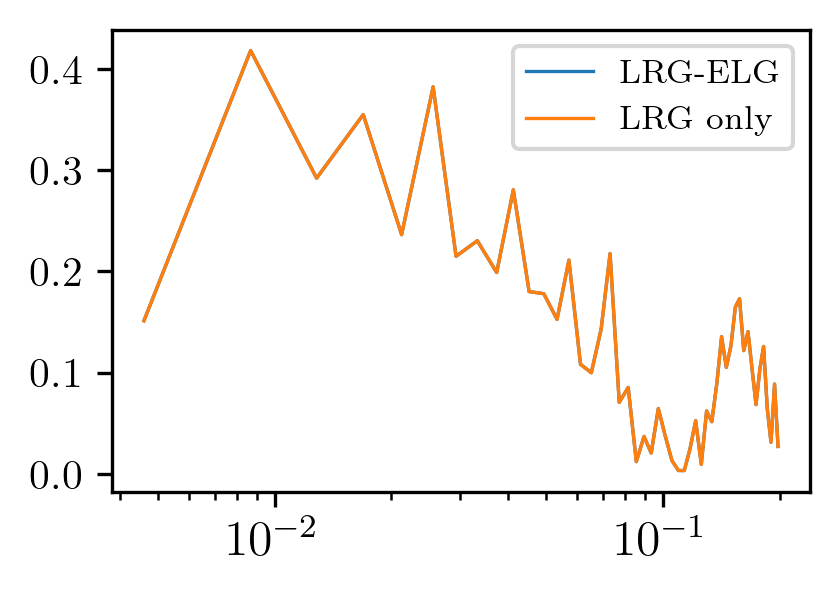

In [114]:
key = "t"

mean_mm_power = [simulations_results[i][key]["auto_ic"][1] for i in simulations_results.keys()]

mean_cross_m_power = [simulations_results[i][key]["cross_sim"][1] for i in simulations_results.keys()]
mean_auto_power = [simulations_results[i][key]["auto_sim"][1] for i in simulations_results.keys()]

mean_cross_lrg_only_m_power = [simulations_results[i][key]["cross_sim_lrg_only"][1] for i in simulations_results.keys()]
mean_auto_lrg_only_power = [simulations_results[i][key]["auto_sim_lrg_only"][1] for i in simulations_results.keys()]

#################################

mean_cross_m_power = np.mean(mean_cross_m_power, axis = 0)
mean_auto_power = np.mean(mean_auto_power, axis = 0)

mean_mm_power = np.mean(mean_mm_power, axis = 0)

mean_cross_lrg_only_m_power = np.mean(mean_cross_lrg_only_m_power, axis = 0)
mean_auto_lrg_only_power = np.mean(mean_auto_lrg_only_power, axis = 0)

r = np.sqrt(mean_cross_m_power**2)/np.sqrt(mean_auto_power*mean_mm_power)
r_lrg_only = np.sqrt(mean_cross_lrg_only_m_power**2)/np.sqrt(mean_auto_lrg_only_power*mean_mm_power)

plt.figure(figsize=(3, 2))
plt.plot(k, r, label = "LRG-ELG")
plt.plot(k, r_lrg_only, label = "LRG only")

plt.xscale("log")
plt.legend()

## Let's get some linear bias

In [115]:
from scipy.optimize import curve_fit

k_max_fit = 0.04 #h/Mpc
key = "g"
mean_lrg_power = [simulations_results[i][key]["cross_sim_lrg_power"][1] for i in simulations_results.keys()]
mean_elg_power = [simulations_results[i][key]["cross_sim_elg_power"][1] for i in simulations_results.keys()]
mean_mm_power = [simulations_results[i][key]["auto_ic"][1] for i in simulations_results.keys()]

mean_lrg_power = np.mean(mean_lrg_power, axis = 0)
mean_elg_power = np.mean(mean_elg_power, axis = 0)
mean_mm_power = np.mean(mean_mm_power, axis = 0)

bias_lrg = mean_lrg_power/mean_mm_power
bias_elg = mean_elg_power/mean_mm_power

selection = k<k_max_fit
k_sel = k[selection]
bias_lrg_sel = bias_lrg[selection]
bias_elg_sel = bias_elg[selection]

func = lambda x, a: a
popt, pcov = curve_fit(func, k_sel, bias_lrg_sel)
bias_lrg = popt[0]

popt, pcov = curve_fit(func, k_sel, bias_elg_sel)
bias_elg = popt[0]

In [116]:
lin_bias_product = bias_lrg*bias_elg
bias_lrg, bias_elg

(1.3293718356579889, 1.5192499827390469)

In [117]:
bA, bB = 0, 0
for i, v in simulations_results.items():
    print(i, v["biases"], "\n")
    bA += v["biases"]['A'][0]
    bB += v["biases"]['B'][0]
bA /= len(simulations_results.keys())
bB /= len(simulations_results.keys())
bA, bB

0 {'A': (1.386731676002041, -1.0935647143751497, 0.000935256375), 'B': (1.5753421545143613, -1.1608225775857381, 0.001315905625)} 

1 {'A': (1.3334805952935074, -0.8675404939331386, 0.000968255125), 'B': (1.5797774969309706, -0.9446159681562423, 0.00131639975)} 

2 {'A': (1.2876416089189753, -1.5520268747002786, 0.00093561125), 'B': (1.5814859331135045, -1.1166838663213827, 0.0013160505)} 

3 {'A': (1.3666863039764159, -1.3606210945339254, 0.000935436375), 'B': (1.5842957789825904, -1.001641056142642, 0.001316524125)} 



(1.3436350460477349, 1.5802253408853566)

In [118]:
print("Bias power frac", bias_lrg, bias_elg)
print("Bias ZCV", bA, bB)

Bias power frac 1.3293718356579889 1.5192499827390469
Bias ZCV 1.3436350460477349 1.5802253408853566


In [119]:
from scipy.optimize import curve_fit

def get_bias(key, kinds):
    normalization = get_norm_opt(key)
    def biasf(x, Cg, Cs, Ct):
        lista = [Cg, Cs, Ct]
        result = np.sum([lista[i]*(normalization*get_norm_opt(key, kk)**-1.) for i, kk in enumerate(kinds)], axis = 0)
        return np.interp(x, Ks, result)
    return biasf

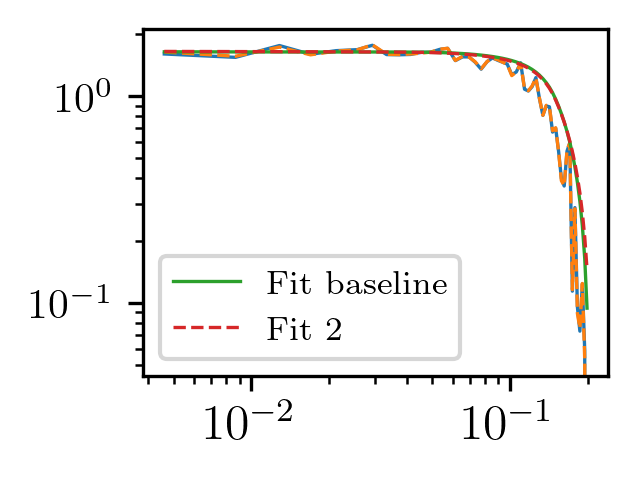

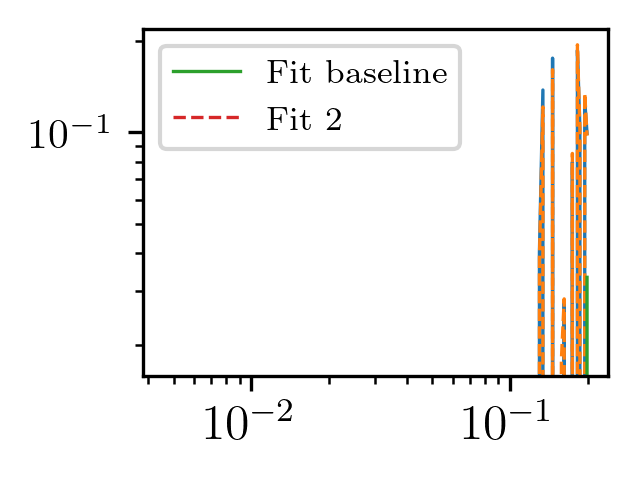

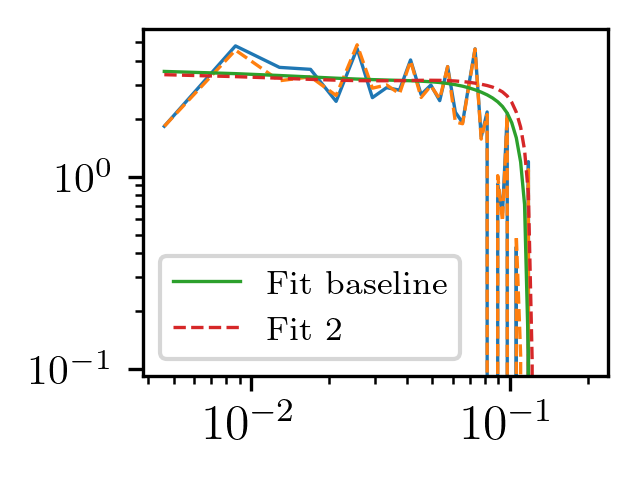

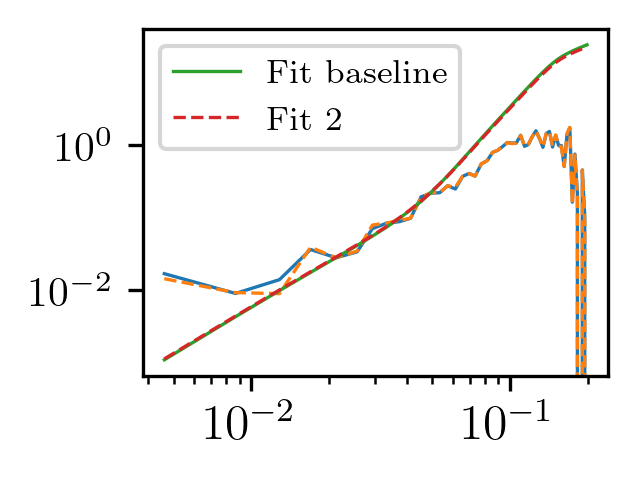

In [120]:
kinds = ["g", "s", "t"]
key_mains = ["g", "s", "t", "n"]

pfits = {}
rhos = {}
for key_main in key_mains:

    bias_crosses = []
    autos = []
    crosses = []
    crosses_lrg = []
    prod = 0
    for simindex, v in simulations_results.items():
        
        results_sim = v[key_main]
        cross, auto, auto_ic, cross_lrg = [results_sim[k][1] for k in ["cross_sim", "auto_sim", "auto_ic", "cross_sim_lrg"]]
        
        normalization = get_norm_opt(key_main)
        normalization_interp = np.interp(k, Ks, normalization)
        bias_cross = cross*normalization_interp/auto_ic
        bias_crosses.append(bias_cross)
        crosses.append(cross*normalization_interp)
        autos.append(auto*normalization_interp**2)
        crosses_lrg.append(cross_lrg*normalization_interp)
        prod += v["biases"]["A"][0]*v["biases"]["B"][0]

    #prod /= len(bias_crosses)
    prod = lin_bias_product
    
    bias_cross_mean = np.mean(bias_crosses, axis = 0)    
    
    cross_mean = np.mean(crosses, axis = 0)

    bias_avg_sims = cross_mean/mean_mm_power
    
    cross_std = np.std(crosses, axis = 0)
    
    cross_lrg_mean = np.mean(crosses_lrg, axis = 0)
    cross_lrg_std = np.std(crosses_lrg, axis = 0)
    
    auto_mean = np.mean(autos, axis = 0)
    auto_std = np.std(autos, axis = 0)

    rhos[key_main] = np.sqrt(cross_mean**2)/np.sqrt(auto_mean*mean_mm_power)
    
    selection = (k<0.051) & (k > 0.003)
    k_sel = k[selection]
    bias_cross_sel = bias_cross_mean[selection]
    bias_avg_sims_sel = bias_avg_sims[selection]

    bias_function = get_bias(key_main, kinds)
    Cs_prod = prod
    func = lambda x, Cg, Ct: bias_function(x, Cg+Cs_prod, Cs_prod, Ct+Cs_prod)
    
    popt, pcov = curve_fit(func, k_sel, bias_cross_sel)
    popt2, _ = curve_fit(func, k_sel, bias_avg_sims_sel)
    
    pfits[key_main] = (popt, bias_cross_mean, auto_mean, cross_mean, auto_std, cross_std, cross_lrg_mean, cross_lrg_std)

    #plt.loglog(k, auto_ic)
    plt.figure(figsize = (2, 1.5))
    plt.loglog(k, (bias_cross_mean))
    plt.loglog(k, (bias_avg_sims), ls = "--")
    plt.plot(k, (func(k, *popt)), label = "Fit baseline")
    plt.plot(k, (func(k, *popt2)), ls = "--", label = "Fit 2")
    plt.legend()
    plt.show()
    

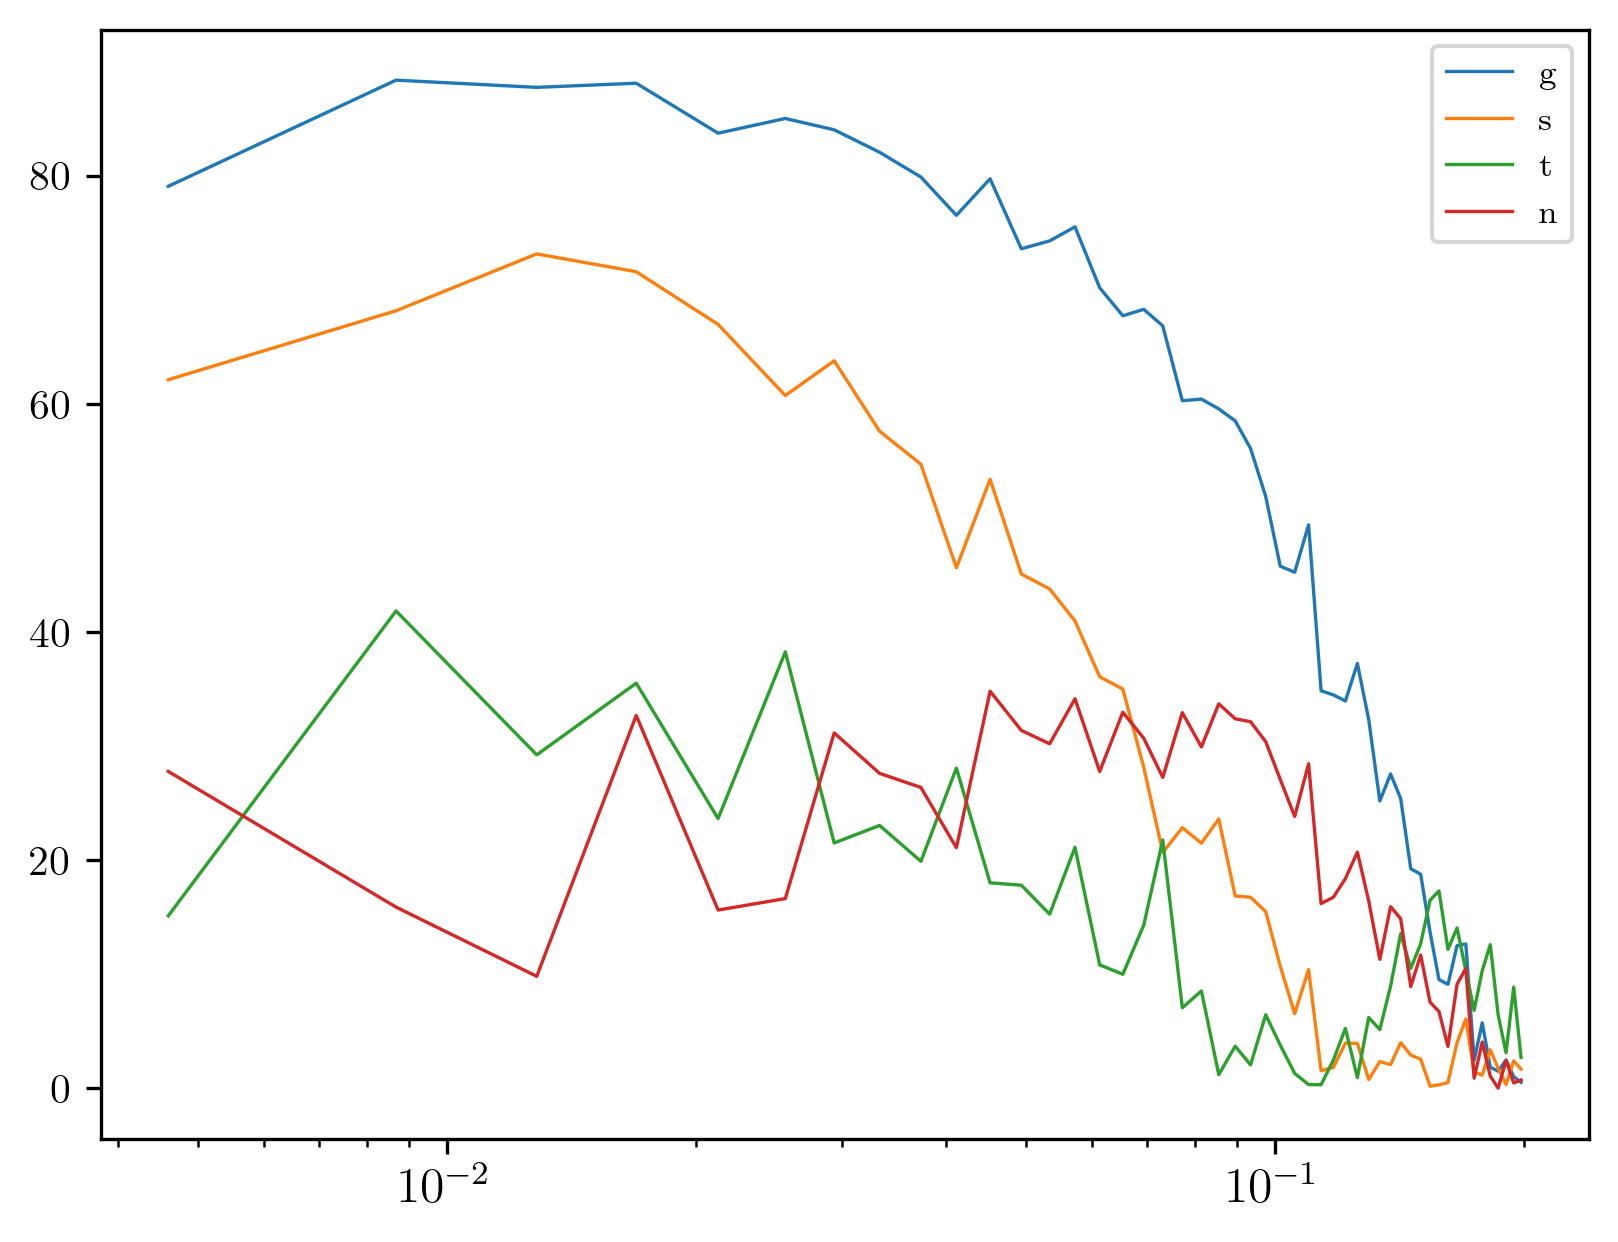

In [121]:
for key_main in key_mains:
    plt.plot(k, 100*rhos[key_main], label = key_main)
plt.xscale("log")
plt.legend()

In [84]:
var_mean = {}
for key_main in key_mains:
    variances = [qres.QEResults(config, relative_path = ".", filename_prefix = f"analysis_AbacusSummit_base_c000_ph{simindex:03}_z0.500_LRG_ELG").get_get_variance()(key_main) for simindex in simulations_results.keys()]
    var_mean[key_main] = np.mean(variances, axis = 0)    

In [85]:
configuration_mean = '../configs/abacus/config_abacus_recs_kmax_20_new_shot_specific_measured_biases.yaml'
with open(configuration_mean, 'r') as f:
    config_mean = yaml.safe_load(f)
QR = qres.QEResults(config_mean, relative_path = ".")
get_norm_opt = QR.get_get_norm()
get_var_opt = QR.get_get_variance()
get_bisp_opt = QR.get_get_bispectrum_mixed()
get_trisp_opt = QR.get_get_trispectrum()


with open(configuration, 'r') as f:
    config = yaml.safe_load(f)

#filename_prefix = f"analysis_AbacusSummit_base_c000_ph{simindex:03}_z0.500_LRG_LRG"
filename_prefix = f"analysis_AbacusSummit_base_c000_ph{simindex:03}_z0.500_LRG_ELG"

QR = qres.QEResults(config, relative_path = ".", filename_prefix = filename_prefix)
get_norm_opt = QR.get_get_norm()
get_var_opt = QR.get_get_variance()
get_bisp_opt = QR.get_get_bispectrum_mixed()
get_trisp_opt = QR.get_get_trispectrum()

In [86]:
Fg_factor = 21/17
g = lambda b1_A, b2_A, b1_B, b2_B: b1_A*b1_B+1/2*21/17*(b1_A*b2_B+b1_B*b2_A) 
s = lambda b1_A, b1_B: b1_A*b1_B
t = lambda b1_A, bs2_A, b1_B, bs2_B:  b1_A*b1_B+1/2*7/2*(b1_A*bs2_B+b1_B*bs2_A) 
biases_rec = {"g": g(out_info_A["b1"], out_info_A["b2"], out_info_B["b1"], out_info_B["b2"]), "s": s(out_info_A["b1"], out_info_B["b1"]), "t": t(out_info_A["b1"], out_info_A["bs"], out_info_B["b1"], out_info_B["bs"])}

In [87]:
for kk in key_mains:
    print(kk, pfits[kk][0])

g [-0.06587245 -2.13146671]
s [-0.04379704 -1.23017565]
t [-0.11691997 -1.03692037]
n [ 4.67863254 42.65210327]


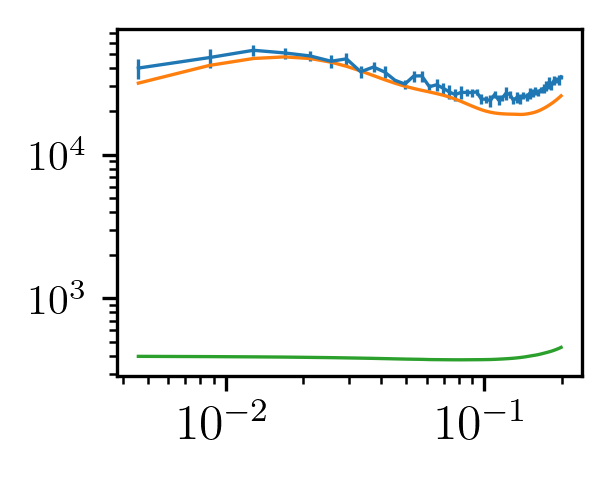

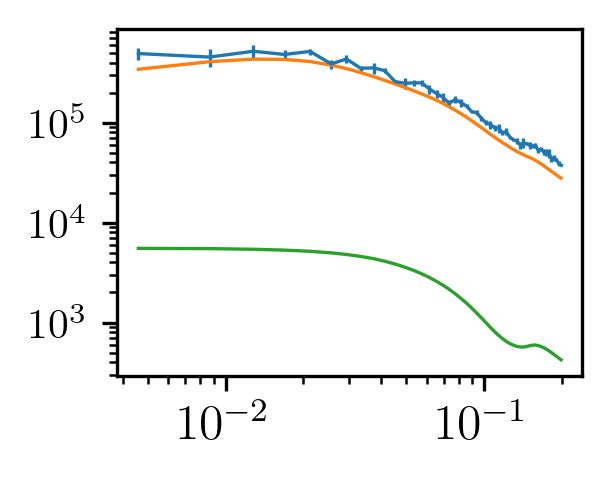

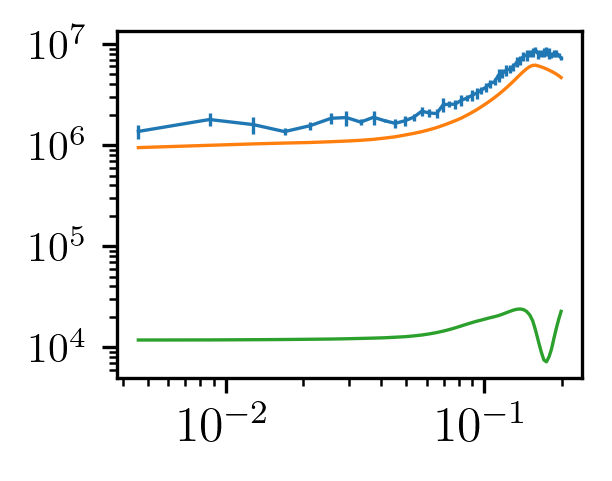

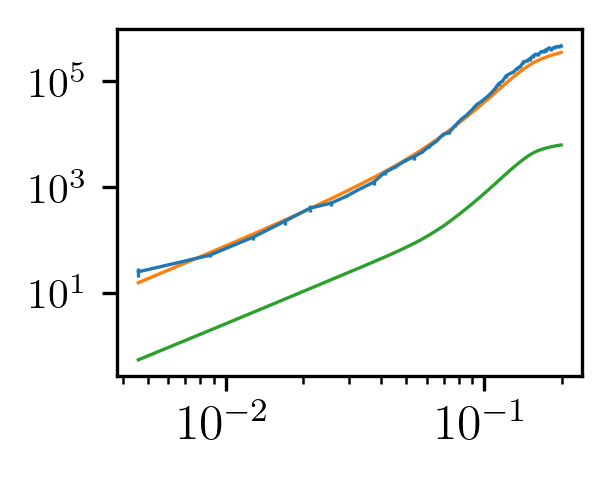

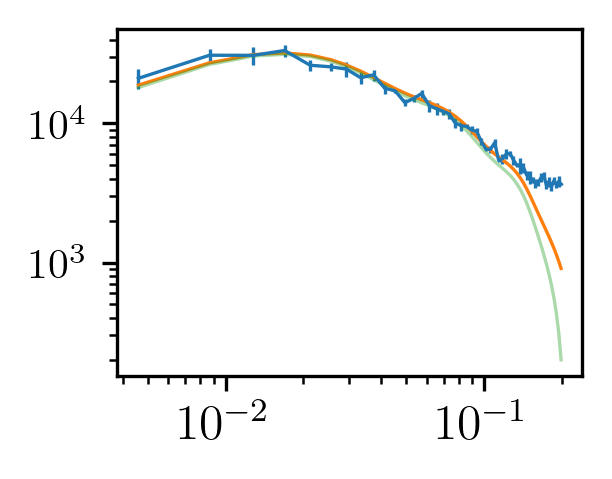

/tmp/ipykernel_73035/441868873.py:34: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.loglog(k, bA*bias*PL+bispectrum)


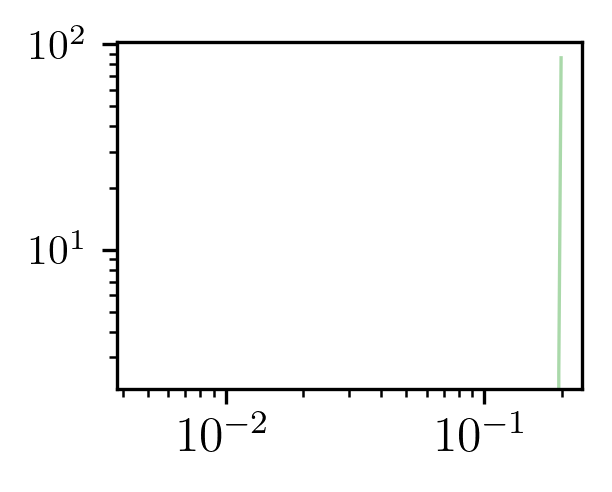

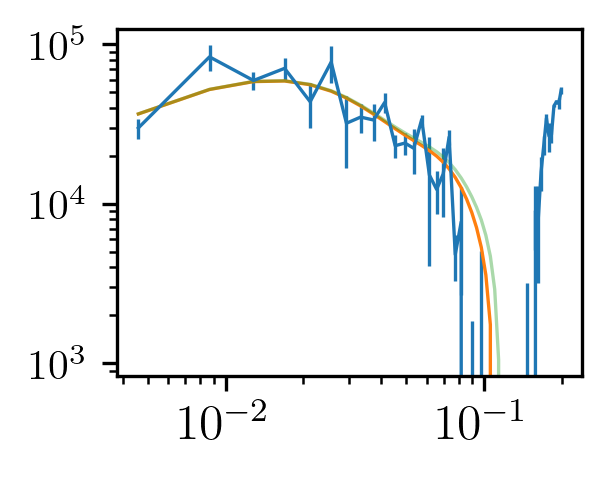

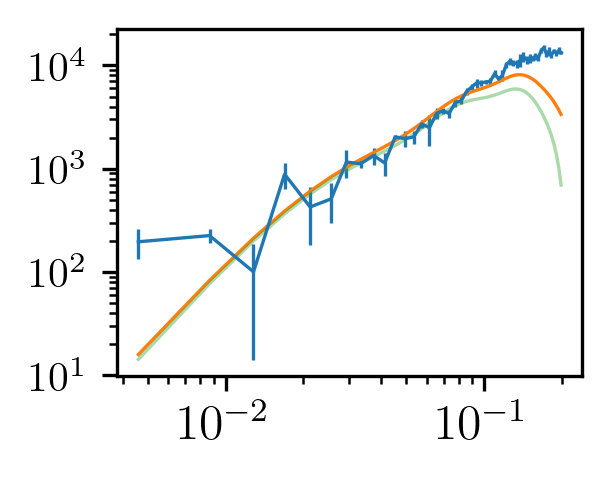

In [88]:
best_overall = [pfits[key_][0][i] for i, key_ in enumerate(["g", "s"])]

Nsims = len(simulations_results.keys())

results_plot = {}
results_matter_plot = {}

for cross in [False, True]:

    temp = {}
    temp_matter = {}
    
    for key_main in key_mains:
    
    
        bias_function = get_bias(key_main, kinds)
        Cs_prod = prod
        func = lambda x, Cg, Ct: bias_function(x, Cg+Cs_prod, Cs_prod, Ct+Cs_prod)
    
        plt.figure(figsize = (2, 1.5))
        
        bias = func(k, *best_overall)

        PL = plinf(k)
        #PL = mean_mm_power
    
        if cross:
            data, err = (pfits[key_main][6]), (pfits[key_main][7])/np.sqrt(Nsims)
            plt.errorbar(k, data, err)
            b_extra = bias_lrg
            bispectrum = np.interp(k, Ks, get_bisp_opt(key_main))
            theory_prediction = bA*bias*PL+bispectrum
            theory_prediction_no_shot = bA*bias*PL
            plt.loglog(k, bA*bias*PL+bispectrum)
            plt.plot(k, bA*bias*PL, alpha = 0.4)
            
            data_matter, err_matter = (pfits[key_main][3]), (pfits[key_main][5])/np.sqrt(Nsims)
            theory_prediction_matter = bias*PL

            temp_matter[key_main] = (k, theory_prediction_matter, data_matter, err_matter)
            results_matter_plot[cross] = temp_matter
        
        else:
            data, err = pfits[key_main][2], (pfits[key_main][4])/np.sqrt(Nsims)
            plt.errorbar(k, data, err)
            variance = np.interp(k, Ks, var_mean[key_main])
            trispectrum = np.interp(k, Ks, get_trisp_opt(key_main))
            theory_prediction_noiseless = bias**2*PL
            theory_prediction = bias**2*PL+variance+trispectrum
            theory_prediction_no_shot = bias**2*PL+variance
            plt.loglog(k, bias**2*PL+variance)
            plt.plot(k, trispectrum)

        plt.show()

        if cross:
            temp[key_main] = (k, theory_prediction, theory_prediction_no_shot, data, err)
        else:
            temp[key_main] = (k, theory_prediction, theory_prediction_no_shot, theory_prediction_noiseless, variance, data, err)
    
    results_plot[cross] = temp
    

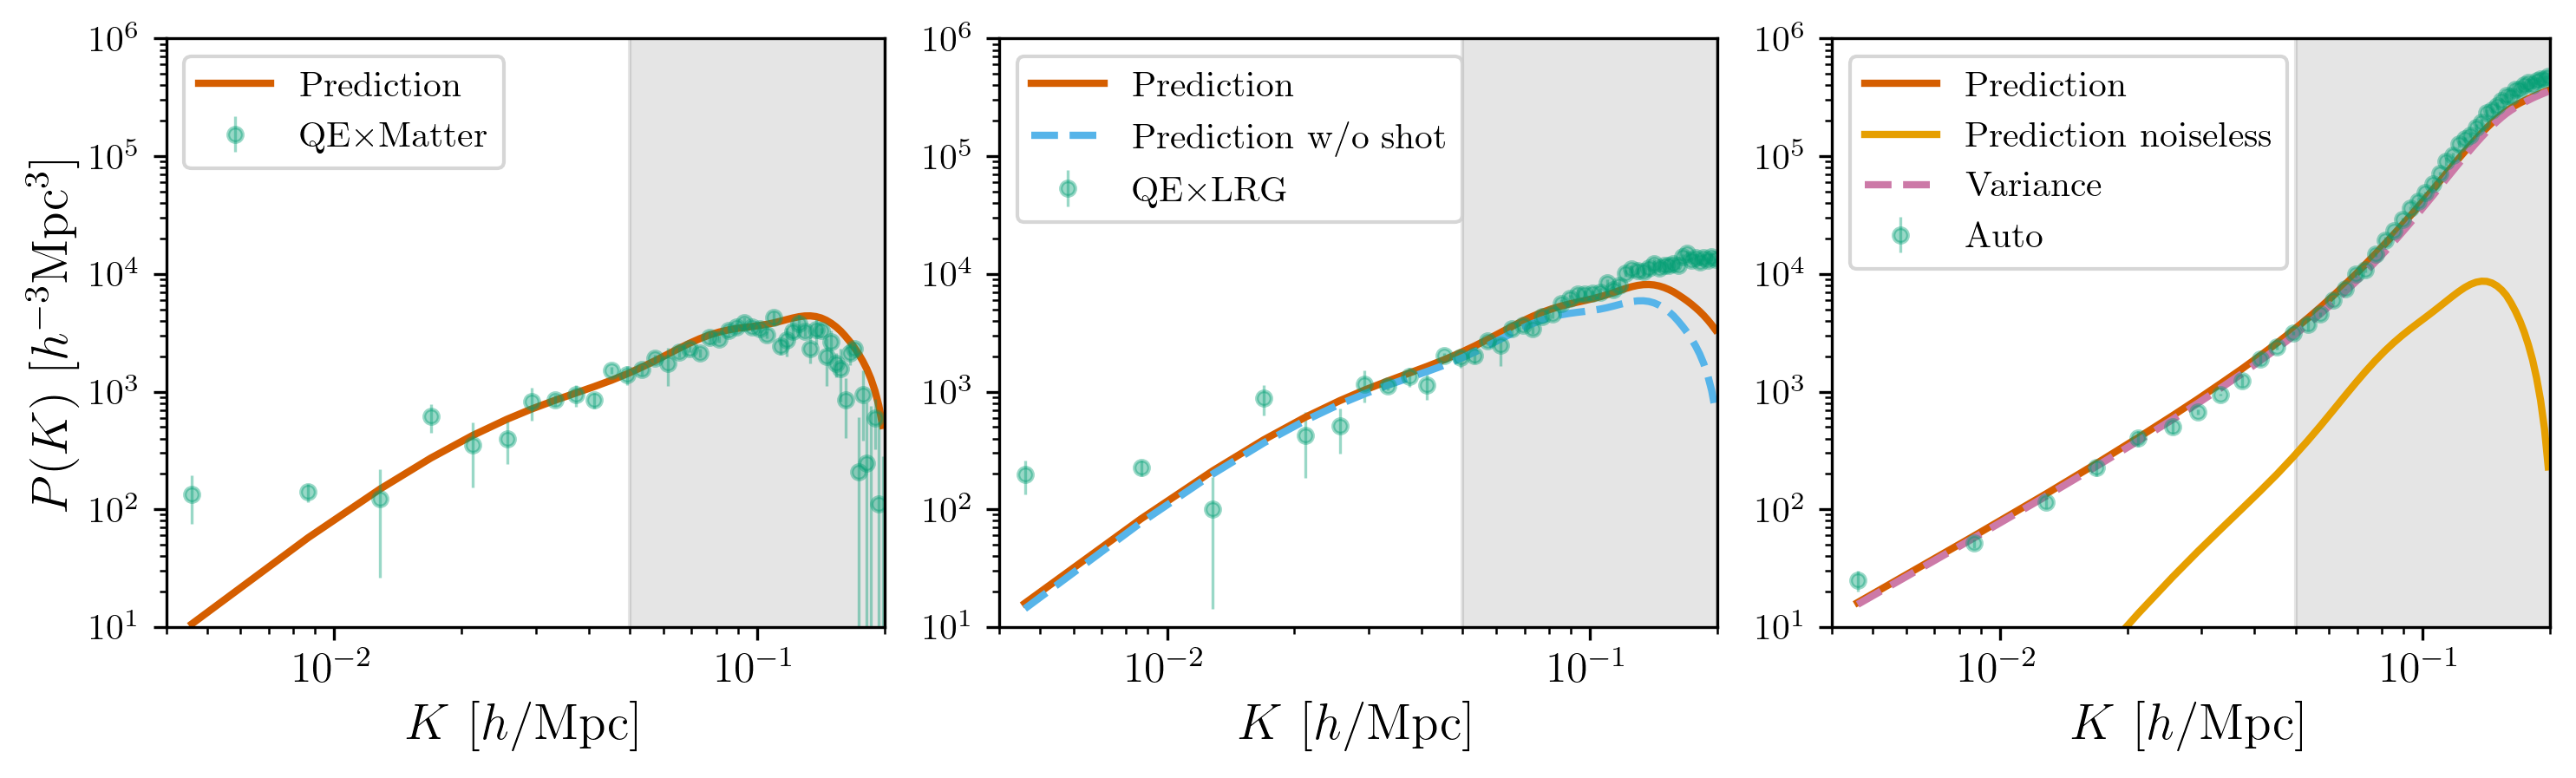

In [89]:
key_main = "n"

GOLDEN_RATIO = (5**0.5 - 1) / 2
FIG_WIDTH = 10  # inches
FIG_HEIGHT = FIG_WIDTH//2 * GOLDEN_RATIO
DPI = 300

normalization = get_norm_opt(key)
variance = get_var_opt(key)

fig = plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT), dpi=DPI, facecolor='white')
# Use GridSpec for more control over plot layout
gs = GridSpec(1, 3, figure=fig)

ax_left = fig.add_subplot(gs[0])

k, theory_prediction_matter, data_matter, err_matter = results_matter_plot[True][key_main]
ax_left.loglog(k, theory_prediction_matter, color = COLORBLIND_PALETTE[1], label = "Prediction", lw = 2)
ax_left.errorbar(k, data_matter, yerr = err_matter,
           fmt='o',  # Circle markers
           markersize = 4,  # Marker size
           color= COLORBLIND_PALETTE[2],
           alpha= 0.4, label = r"QE$\times$Matter")
ax_left.fill_betweenx([1e-5, 1e8], 0.05, 0.2, color = "black", alpha = 0.1)
ax_left.set_xlabel(r'$K \ [h/\mathrm{Mpc}]$', fontsize=14)
ax_left.legend(fontsize = 10, loc = "upper left")
ax_left.set_ylabel(r'$P(K) \ [h^{-3}\mathrm{Mpc^{3}]}$', fontsize=14)
ax_left.set_xlim(4e-3, 0.2)
ax_left.set_ylim(10, 1e6)

ax_left = fig.add_subplot(gs[1], sharey=ax_left)
cross = True
k, theory_prediction, theory_prediction_no_shot, data, err = results_plot[cross][key_main]
ax_left.errorbar(k, data, yerr = err,
           fmt='o',  # Circle markers
           markersize = 4,  # Marker size
           color= COLORBLIND_PALETTE[2],
           alpha= 0.4, label = r"QE$\times$LRG")

ax_left.loglog(k, theory_prediction,color = COLORBLIND_PALETTE[1], label = "Prediction", lw = 2)
ax_left.loglog(k, theory_prediction_no_shot, color = COLORBLIND_PALETTE[4], label = "Prediction w/o shot", lw = 2, ls = "--")

ax_left.set_xlabel(r'$K \ [h/\mathrm{Mpc}]$', fontsize=14)
#ax_left.loglog(Ks, get_bisp_opt_new(key), label = "Bispectrum", color = COLORBLIND_PALETTE[5], lw = 2, ls = "--")
ax_left.legend(fontsize = 10, loc = "upper left")
ax_left.set_xlim(4e-3, 0.2)
ax_left.set_ylim(10)
ax_left.fill_betweenx([1e-5, 1e8], 0.05, 0.2, color = "black", alpha = 0.1)
ax_left.set_ylim(10, 1e6)

ax = fig.add_subplot(gs[2])
cross = False
k, theory_prediction, theory_prediction_no_shot, theory_prediction_noiseless, variance, data, err = results_plot[cross][key_main]

#plt.setp(ax.get_yticklabels(), visible=False)

ax.loglog(k, theory_prediction, color = COLORBLIND_PALETTE[1], label = "Prediction", lw = 2)

ax.loglog(k, theory_prediction_noiseless, color = COLORBLIND_PALETTE[5], label = "Prediction noiseless", lw = 2)
#ax.loglog(k, theory_prediction_no_shot, color = COLORBLIND_PALETTE[4], label = "Prediction w/o shot", lw = 2, ls = "-")

ax.loglog(k, variance, color = COLORBLIND_PALETTE[3], label = "Variance", lw = 2, ls = "--")


#ax.loglog(Ks, variance, label = "Variance", color = COLORBLIND_PALETTE[3], lw = 2, ls = "--")

ax.errorbar(k, data, yerr = err, #yerr=final_results["auto"][1], 
           fmt='o',  # Circle markers
           markersize = 4,  # Marker size
           color= COLORBLIND_PALETTE[2],
           alpha= 0.4, label = "Auto")

#ax.plot(Ks, (tri), color = COLORBLIND_PALETTE[7], label = "Mixed trispectrum", lw = 2)

#ax.plot(Ks, (plinf(Ks)), color = "black", lw = 3)
ax.fill_betweenx([1e-5, 1e8], 0.05, 0.2, color = "black", alpha = 0.1)
ax.set_xlim(4e-3, 0.2)
ax.set_ylim(10, 1e6)

ax.legend(fontsize = 10, loc = "upper left")
ax.set_xlabel(r'$K \ [h/\mathrm{Mpc}]$', fontsize=14)


extra = "" if kmax == 0.1 else f"_kmax_{kmax}"
fig.savefig(f"/users/odarwish/long-modes/figures/matter_biased_lrg_elg_sims{extra}.pdf", dpi = 300, bbox_inches='tight')
fig.tight_layout()

plt.show()

In [ ]:
key_main = "n"

GOLDEN_RATIO = (5**0.5 - 1) / 2
FIG_WIDTH = 10  # inches
FIG_HEIGHT = FIG_WIDTH//2 * GOLDEN_RATIO
DPI = 300

fig = plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT), dpi=DPI, facecolor='white')
# Use GridSpec for more control over plot layout
gs = GridSpec(1, 1, figure=fig)

ax_left = fig.add_subplot(gs[0])



ax_left.loglog(k, theory_prediction_matter, color = COLORBLIND_PALETTE[1], label = "Prediction", lw = 2)
ax_left.errorbar(k, data_matter, yerr = err_matter,
           fmt='o',  # Circle markers
           markersize = 4,  # Marker size
           color= COLORBLIND_PALETTE[2],
           alpha= 0.4, label = r"QE$\times$Matter")

ax_left.fill_betweenx([1e-5, 1e8], 0.05, 0.2, color = "black", alpha = 0.1)
ax_left.set_xlabel(r'$K \ [h/\mathrm{Mpc}]$', fontsize=14)
ax_left.legend(fontsize = 10, loc = "upper left")
ax_left.set_ylabel(r'$P(K) \ [h^{-3}\mathrm{Mpc^{3}]}$', fontsize=14)
ax_left.set_xlim(4e-3, 0.2)
ax_left.set_ylim(10, 1e6)

extra = "" if kmax == 0.1 else f"_kmax_{kmax}"
fig.savefig(f"/users/odarwish/long-modes/figures/rho_comparison{extra}.pdf", dpi = 300, bbox_inches='tight')
fig.tight_layout()

plt.show()